In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
insurance_data = pd.read_csv("insurance.csv")

In [4]:
insurance_data

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


<Axes: xlabel='bmi', ylabel='charges'>

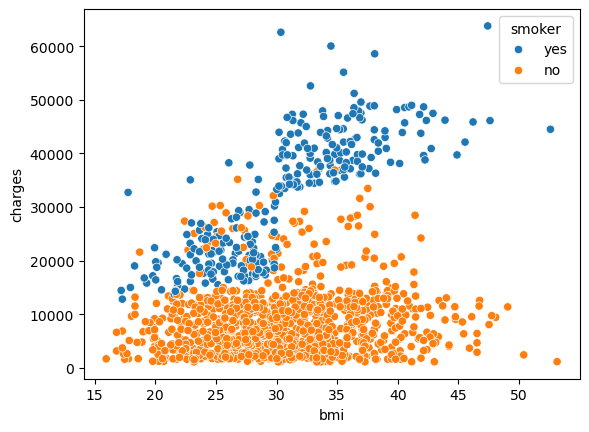

In [9]:
sns.scatterplot(x=insurance_data["bmi"],y=insurance_data["charges"],hue=insurance_data["smoker"])

In [10]:
# x for inputs , y for output
# feature data into numbers as possbile

X= insurance_data.drop(columns = ["charges","region"])
Y = insurance_data["charges"]

X["sex"] = X["sex"].map({"female":1,"male":0})
X["smoker"] = X["smoker"].map({"yes":1,"no":0})


In [13]:
X.head()

,age,sex,bmi,children,smoker
0,19,1,27.900,0,1
1,18,0,33.770,1,0
2,28,0,33.000,3,0
3,33,0,22.705,0,0
4,32,0,28.880,0,0


In [15]:
#Train Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42)


In [16]:
X_train.head()

,age,sex,bmi,children,smoker
560,46,1,19.95,2,0
1285,47,1,24.32,0,0
1142,52,1,24.86,0,0
969,39,1,34.32,5,0
486,54,1,21.47,3,0


In [17]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [18]:
#predict values

y_pred = model.predict(X_test)

In [19]:
y_pred

array([ 8554.81711589,  6973.58746745, 36798.60416104,  9417.88282303,
       26871.68031081, 11097.38383938,   145.27608963, 16746.1683771 ,
         747.53414191, 11153.67590722, 28518.15016561,  9292.18345421,
        5460.51975119, 38510.48013003, 40359.30938604, 37223.40538064,
       15316.56711945, 36047.50032223,  9326.29049907, 31400.1559532 ,
        4269.64414373, 10464.66374097,  2719.9260555 ,  6579.53742551,
       11232.00255515, 12472.06793446, 14807.11281089,  6066.19283362,
        9535.69029723,  2377.6983797 ,  9475.05690885, 12963.23366722,
        4706.09057393,  3414.674504  ,  4815.64981654, 12484.17176954,
        2359.13614479,  9161.02061228, 33238.67621442, 32743.41702445,
        4274.58967205,  4229.5442107 , 14435.36485176, 11384.66898976,
        8925.70468583, 12480.09178788,  5154.45787816,  3554.10047649,
       35649.60942684,  9276.25523701, 15971.35991397,  2552.75200479,
       12162.99980138,  1062.65132285, 13551.43771934, 12103.65505529,
      

In [20]:
y_test

764      9095.06825
887      5272.17580
890     29330.98315
1293     9301.89355
259     33750.29180
           ...     
109     47055.53210
575     12222.89830
535      6067.12675
543     63770.42801
846      9872.70100
Name: charges, Length: 268, dtype: float64

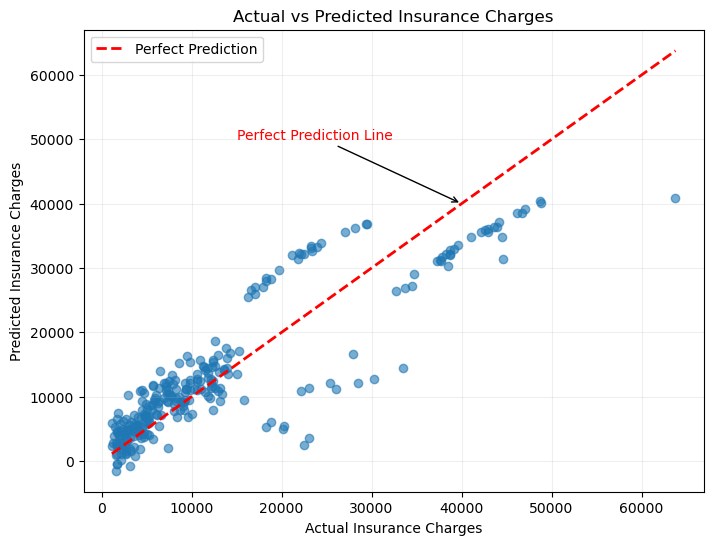

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

# Actual vs Predicted
plt.scatter(
    y_test,
    y_pred,
    alpha=0.6
)

# Labels
plt.xlabel("Actual Insurance Charges")
plt.ylabel("Predicted Insurance Charges")
plt.title("Actual vs Predicted Insurance Charges")

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--",
    linewidth=2,
    label="Perfect Prediction"
)

# Annotation
plt.annotate(
    "Perfect Prediction Line",
    xy=(40000, 40000),
    xytext=(15000, 50000),
    arrowprops=dict(arrowstyle="->"),
    color="red"
)

plt.legend()
plt.grid(alpha=0.2)

plt.show()

In [26]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
import numpy as np

r2 = r2_score(y_test,y_pred)
mae = mean_absolute_error(y_test,y_pred)
rmse = np.sqrt(mean_squared_error(y_test,y_pred))

print("R2 Score :",r2)
print("MAE :",mae)
print("RMSE :",rmse)

R2 Score : 0.7811302113434095
MAE : 4213.484797807139
RMSE : 5829.17293025419


# Encoding

In [5]:
# x for inputs , y for output
# feature data into numbers as possbile

X= insurance_data.drop(columns = ["charges"])
Y = insurance_data["charges"]

X = pd.get_dummies(X,columns=["region"],drop_first=False)
X["sex"] = X["sex"].map({"female":1,"male":0})
X["smoker"] = X["smoker"].map({"yes":1,"no":0})

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42)

from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [7]:
y_pred = model.predict(X_test)
y_pred

array([ 8969.55027444,  7068.74744287, 36858.41091155,  9454.67850053,
       26973.17345656, 10864.11316424,   170.28084137, 16903.45028662,
        1092.43093614, 11218.34318352, 28101.68455267,  9377.73460205,
        5263.0595179 , 38416.04221107, 40255.82339284, 37098.25353123,
       15240.39392306, 35912.88264434,  9112.52398703, 31461.92108909,
        3847.68845883, 10130.12001517,  2370.54189389,  7140.21550828,
       11301.76782638, 12961.65366224, 14509.47251876,  6159.8976107 ,
        9963.85857263,  2177.85718217,  9115.93673493, 13073.68932159,
        4561.82376202,  3408.20756033,  4459.81359745, 13032.06505076,
        1979.99357292,  8813.28303302, 33271.29124448, 32585.51583927,
        3908.76090964,  4326.10774721, 14142.81326533, 11423.45494846,
        8774.13955311, 12097.28051001,  5281.57353499,  3150.5596042 ,
       35494.46461214,  9150.1124786 , 15836.84575621,  2343.57470069,
       12364.78414194,  1482.29488266, 13389.06105161, 12573.57395972,
      

In [8]:
y_test

764      9095.06825
887      5272.17580
890     29330.98315
1293     9301.89355
259     33750.29180
           ...     
109     47055.53210
575     12222.89830
535      6067.12675
543     63770.42801
846      9872.70100
Name: charges, Length: 268, dtype: float64

In [9]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
import numpy as np

r2 = r2_score(y_test,y_pred)
mae = mean_absolute_error(y_test,y_pred)
rmse = np.sqrt(mean_squared_error(y_test,y_pred))

print("R2 Score :",r2)
print("MAE :",mae)
print("RMSE :",rmse)

R2 Score : 0.7835929767120723
MAE : 4181.194473753642
RMSE : 5796.2846592762735


# Interaction Feature

In [5]:
# x for inputs , y for output
# feature data into numbers as possbile

X= insurance_data.drop(columns = ["charges"])
Y = insurance_data["charges"]

X = pd.get_dummies(X,columns=["region"],drop_first=False)
X["sex"] = X["sex"].map({"female":1,"male":0})
X["smoker"] = X["smoker"].map({"yes":1,"no":0})

X["age_smoker"] = X["age"]*X["smoker"]
X["bmi_smoker"] = X["bmi"]*X["smoker"]

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42)

from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train,y_train)

y_pred = model.predict(X_test)

from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
import numpy as np

r2 = r2_score(y_test,y_pred)
mae = mean_absolute_error(y_test,y_pred)
rmse = np.sqrt(mean_squared_error(y_test,y_pred))

print("R2 Score :",r2)
print("MAE :",mae)
print("RMSE :",rmse)

R2 Score : 0.865231697953168
MAE : 2757.759204250129
RMSE : 4574.123734451315


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train,y_train)
y_pred = model.predict(X_test)